# FNN Regressor — GraceWanjaB30299_2.ipynb
**GRACE WANJA BSDS 2:1**  
**Task:** To Train a Feedforward Neural Network regressor using `train_set2.csv` and evaluate on `test_set2.csv`.


In [1]:
# imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
print("CWD:", os.getcwd())
print("Files:", os.listdir('.'))


CWD: D:\AI TEST\Test 2 Data
Files: ['.git', '.ipynb_checkpoints', 'best_model1.h5', 'classification_report.csv', 'confusion_matrix.csv', 'Grace_WanjaB30299.ipynb', 'model1.keras', 'test_set1.csv', 'test_set2.csv', 'train_set1.csv', 'train_set2.csv', 'Untitled.ipynb']


In [3]:
train_path = "train_set2.csv"
test_path  = "test_set2.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (5760, 11)
Test shape: (1440, 11)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,target
0,5.1837,5.2589,4.7416,3.4497,6.0757,4.6659,6.1109,3.0255,4.6229,4.3062,48.679
1,3.4465,6.7194,4.6754,5.4218,4.6044,4.1345,6.3372,2.7389,5.8906,4.9094,-243.500
2,3.5547,8.1908,3.5902,2.7511,3.7946,5.3680,3.4840,3.9785,3.7648,2.0782,302.060
3,5.9537,4.0416,6.8824,3.0503,3.6590,3.3485,6.0540,4.2236,5.2342,5.1399,70.597
4,4.7517,4.1695,5.7002,5.7010,4.2282,5.4714,4.4265,2.4007,6.7714,7.6036,156.670


### EDA
Check for missing values and basic statistics.


In [4]:
print("Missing (train):\n", train_df.isna().sum())
print("Missing (test):\n", test_df.isna().sum())

display(train_df.describe().T)


Missing (train):
 F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
F9        0
F10       0
target    0
dtype: int64
Missing (test):
 F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
F9        0
F10       0
target    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
F1,5760.0,5.207207,1.498699,-0.356530,4.187075,5.19860,6.241800,10.442
F2,5760.0,5.206252,1.542186,-0.204040,4.166225,5.17495,6.253525,11.524
F3,5760.0,5.179866,1.528878,-0.195900,4.155350,5.17180,6.201050,10.713
F4,5760.0,5.180154,1.548766,-0.814240,4.137075,5.15950,6.196225,11.569
F5,5760.0,5.228497,1.509607,0.172290,4.186400,5.22400,6.238925,11.161
F6,5760.0,5.209557,1.531062,-0.059266,4.177150,5.20140,6.222650,11.158
F7,5760.0,5.168840,1.538608,-0.276580,4.118125,5.17680,6.211700,10.373
F8,5760.0,5.190551,1.530448,-0.680800,4.169400,5.20620,6.211475,10.823
F9,5760.0,5.206883,1.518786,0.114240,4.188025,5.20550,6.233925,10.251
F10,5760.0,5.230459,1.542108,0.131950,4.170300,5.25705,6.272475,10.815


### spliting  features & target, scaling
Use StandardScaler on inputs. For regression targets, optionally scale if target range is large; below we keep target unscaled so metrics are interpretable — but I include commented code to scale the target if desired.


In [5]:
# assuming last column is target
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# scale features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Optionally scale target (uncomment if needed)
# scaler_y = StandardScaler()
# y_train = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
# y_test  = scaler_y.transform(y_test.reshape(-1,1)).ravel()

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)


X_train shape: (5760, 10) y_train shape: (5760,)


### model designing & justification
**Proposed architecture (chosen):**
- Input: number of features (D)
- Dense(64, ReLU) ; allows learning many feature combinations
- Dense(32, ReLU) ; reduces dimensionality and learns higher-level features
- Dense(16, ReLU) ; refinement
- Dense(1, linear) ; regression output

**Regularization and other choices:**
- Dropout(0.2) after first hidden layer to reduce overfitting (optional for regression)
- BatchNormalization can be added after dense layers to stabilize training (optional)
- Loss: Mean Squared Error (MSE) , standard for regression
- Optimizer: Adam (lr=1e-3) , adaptive and robust
- Metrics reported: MSE, RMSE, MAE, R² (R² computed via sklearn)
- EarlyStopping on validation loss with patience=10
- ModelCheckpoint to save the best weights


In [6]:
# building the model 
def build_regressor(input_shape, lr=1e-3, dropout_rate=0.2, use_batchnorm=False):
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Dense(64, activation='relu')(inputs)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation='relu')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs)
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

input_shape = X_train.shape[1]
model = build_regressor(input_shape, lr=1e-3, dropout_rate=0.2, use_batchnorm=False)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

### hyperparameters (chosen) & callbacks
**Hyperparameters (justification):**
- lr = 0.001: Adam default; good starting point
- batch_size = 32: stable gradient estimates, common default
- epochs = 200 with EarlyStopping(patience=10): allow sufficient training but stop when no improvement
- validation_split = 0.2: hold-out from training for validation monitoring


In [8]:
# training hyperparameters
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 200

# callbacks
checkpoint_path = "best_model2.h5"
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
mc = callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1, min_lr=1e-6)


In [9]:
# training the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, mc, reduce_lr],
    verbose=2
)


Epoch 1/200

Epoch 1: val_loss improved from None to 185871.01562, saving model to best_model2.h5


144/144 - 3s - 24ms/step - loss: 230126.5000 - mae: 375.9229 - val_loss: 185871.0156 - val_mae: 339.6036 - learning_rate: 0.0010
Epoch 2/200

Epoch 2: val_loss improved from 185871.01562 to 19874.41797, saving model to best_model2.h5


144/144 - 1s - 6ms/step - loss: 67948.2656 - mae: 177.9913 - val_loss: 19874.4180 - val_mae: 93.1152 - learning_rate: 0.0010
Epoch 3/200

Epoch 3: val_loss improved from 19874.41797 to 10156.35840, saving model to best_model2.h5


144/144 - 1s - 9ms/step - loss: 18929.0039 - mae: 90.7852 - val_loss: 10156.3584 - val_mae: 70.5771 - learning_rate: 0.0010
Epoch 4/200

Epoch 4: val_loss improved from 10156.35840 to 6729.18164, saving model to best_model2.h5


144/144 - 1s - 5ms/step - loss: 11986.2998 - mae: 77.0746 - val_loss: 6729.1816 - val_mae: 58.5722 - learning_rate: 0.0010
Epoch 5/200

Epoch 5: val_loss improved from 6729.18164 to 5308.02783, saving model to best_model2.h5


...

144/144 - 1s - 5ms/step - loss: 4107.4258 - mae: 45.1930 - val_loss: 1799.0341 - val_mae: 30.3325 - learning_rate: 0.0010
Epoch 49/200

Epoch 49: val_loss improved from 1799.03406 to 1711.08508, saving model to best_model2.h5


144/144 - 1s - 10ms/step - loss: 4093.0212 - mae: 45.4966 - val_loss: 1711.0851 - val_mae: 29.0172 - learning_rate: 0.0010
Epoch 50/200

Epoch 50: val_loss did not improve from 1711.08508
144/144 - 1s - 8ms/step - loss: 4044.4465 - mae: 45.0732 - val_loss: 1878.2455 - val_mae: 30.6186 - learning_rate: 0.0010
Epoch 51/200

Epoch 51: val_loss did not improve from 1711.08508
144/144 - 1s - 5ms/step - loss: 3919.9443 - mae: 44.6780 - val_loss: 1951.5938 - val_mae: 31.1514 - learning_rate: 0.0010
Epoch 52/200

Epoch 52: val_loss did not improve from 1711.08508
144/144 - 1s - 5ms/step - loss: 3956.4714 - mae: 44.4999 - val_loss: 1845.5623 - val_mae: 30.3042 - learning_rate: 0.0010
Epoch 53/200

Epoch 53: val_loss did not improve from 1711.08508
144/144 - 1s - 9ms/step - loss: 3774.7573 - mae: 43.5969 - val_loss: 1781.9888 - val_mae: 30.4923 - learning_rate: 0.0010
Epoch 54/200

Epoch 54: val_loss improved from 1711.08508 to 1680.42480, saving model to best_model2.h5


144/144 - 1s - 6ms/step - loss: 4158.0986 - mae: 44.7927 - val_loss: 1680.4248 - val_mae: 29.0786 - learning_rate: 0.0010
Epoch 55/200

Epoch 55: val_loss did not improve from 1680.42480
144/144 - 1s - 5ms/step - loss: 3736.7998 - mae: 42.8424 - val_loss: 1828.7717 - val_mae: 29.9543 - learning_rate: 0.0010
Epoch 56/200

Epoch 56: val_loss did not improve from 1680.42480
144/144 - 1s - 5ms/step - loss: 3661.2109 - mae: 43.0838 - val_loss: 1745.5233 - val_mae: 29.6479 - learning_rate: 0.0010
Epoch 57/200

Epoch 57: val_loss did not improve from 1680.42480
144/144 - 1s - 9ms/step - loss: 3466.7217 - mae: 42.2369 - val_loss: 1785.0331 - val_mae: 30.0806 - learning_rate: 0.0010
Epoch 58/200

Epoch 58: val_loss improved from 1680.42480 to 1667.92371, saving model to best_model2.h5


144/144 - 1s - 6ms/step - loss: 3754.0574 - mae: 42.8938 - val_loss: 1667.9237 - val_mae: 29.0044 - learning_rate: 0.0010
Epoch 59/200

Epoch 59: val_loss did not improve from 1667.92371
144/144 - 1s - 8ms/step - loss: 3656.6338 - mae: 42.6710 - val_loss: 1807.1836 - val_mae: 31.0078 - learning_rate: 0.0010
Epoch 60/200

Epoch 60: val_loss improved from 1667.92371 to 1604.08643, saving model to best_model2.h5


144/144 - 1s - 9ms/step - loss: 3556.5081 - mae: 41.9835 - val_loss: 1604.0864 - val_mae: 28.6971 - learning_rate: 0.0010
Epoch 61/200

Epoch 61: val_loss did not improve from 1604.08643
144/144 - 1s - 5ms/step - loss: 3454.0386 - mae: 41.7956 - val_loss: 1722.2190 - val_mae: 30.0354 - learning_rate: 0.0010
Epoch 62/200

Epoch 62: val_loss did not improve from 1604.08643
144/144 - 1s - 10ms/step - loss: 3223.8899 - mae: 41.1512 - val_loss: 1760.8262 - val_mae: 29.9504 - learning_rate: 0.0010
Epoch 63/200

Epoch 63: val_loss did not improve from 1604.08643
144/144 - 1s - 9ms/step - loss: 3305.8633 - mae: 41.1473 - val_loss: 1647.5443 - val_mae: 29.3921 - learning_rate: 0.0010
Epoch 64/200

Epoch 64: val_loss did not improve from 1604.08643
144/144 - 1s - 4ms/step - loss: 3285.1680 - mae: 41.3252 - val_loss: 1952.7227 - val_mae: 31.4714 - learning_rate: 0.0010
Epoch 65/200

Epoch 65: val_loss did not improve from 1604.08643
144/144 - 1s - 5ms/step - loss: 3529.7168 - mae: 42.0098 - val_l

Saved final model to model2.keras and best checkpoint: best_model2.h5


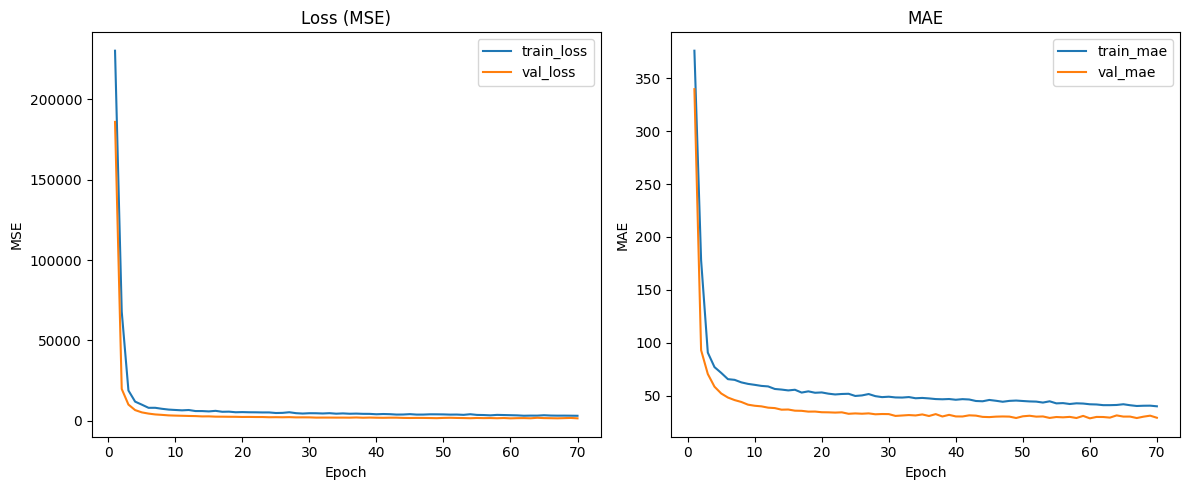

In [10]:
model.save("model2.keras")  # preferred new format
print("Saved final model to model2.keras and best checkpoint:", checkpoint_path)

# plot training curves
hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, hist['loss'], label='train_loss')
plt.plot(epochs_range, hist['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.title('Loss (MSE)')

plt.subplot(1,2,2)
plt.plot(epochs_range, hist.get('mae', []), label='train_mae')
plt.plot(epochs_range, hist.get('val_mae', []), label='val_mae')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.title('MAE')
plt.tight_layout()
plt.show()


### evaluating on test set ie computing metrics
We compute MSE, RMSE, MAE, R² and also show a scatter plot of true vs predicted to visualize residuals.


In [11]:
# loading best checkpoint to be safe
best_model = keras.models.load_model(checkpoint_path)

# predict
y_pred = best_model.predict(X_test).ravel()

# if target was scaled, inverse transform here:
# y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE:  {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE:  {mae:.6f}")
print(f"Test R2:   {r2:.6f}")


ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [13]:
# Loading the trained model safely and evaluating on test data 

from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Loading the best checkpoint (disable compile to avoid Keras deserialization error)
best_model = keras.models.load_model(checkpoint_path, compile=False)

# Recompile manually if you plan to evaluate metrics during training
best_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mean_squared_error', 'mae']
)

# Make predictions
y_pred = best_model.predict(X_test).ravel()

# Compute regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Model Evaluation Results")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

# --- Optional: Save final model for submission ---
best_model.save("model2.h5")
print("\nModel saved successfully as model2.h5")


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Model Evaluation Results
Mean Squared Error (MSE): 1729.3679
Root Mean Squared Error (RMSE): 41.5857
Mean Absolute Error (MAE): 28.0224
Coefficient of Determination (R²): 0.9893

Model saved successfully as model2.h5
